<a href="https://colab.research.google.com/github/aehr-canter/waterwais/blob/main/WaterwAIs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Leak Detection and Anomaly Detection Code**



Dataset Upload and Imports

In [ ]:
import pandas as pd

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

from sklearn.svm import OneClassSVM

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [ ]:
file_path = '/content/drive/MyDrive/Non-Trivial Submission/Leak and Anamoly Detection/water_network_with_failure_and_gis.csv'
df = pd.read_csv(file_path)

Isolation Forest

In [ ]:
numerical_cols = ['PipeAge', 'Length_m', 'Diameter_mm', 'Pressure_psi', 'FlowRate_Lps']
X = df[numerical_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
iso_forest.fit(X_scaled)

df['anomaly_score_iso'] = iso_forest.decision_function(X_scaled)
df['anomaly_iso'] = iso_forest.predict(X_scaled).astype(int)

df['anomaly_iso'] = df['anomaly_iso'].map({1: 0, -1: 1})

anomaly_count = df['anomaly_iso'].sum()

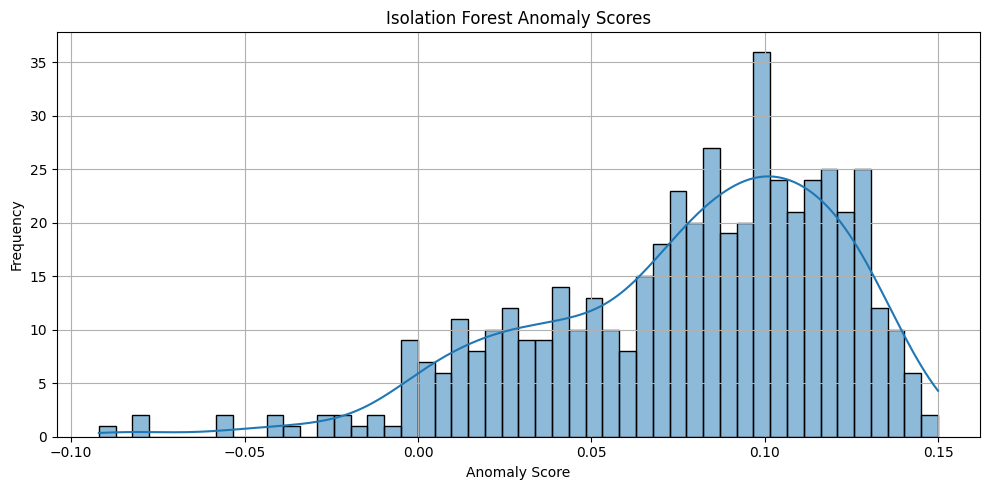

np.int64(25)

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['anomaly_score_iso'], bins=50, kde=True)
plt.title('Isolation Forest Anomaly Scores')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

anomaly_count

Autoencoder

In [ ]:
file_path2 = '/content/drive/MyDrive/Non-Trivial Submission/Leak and Anamoly Detection/water_network_with_failure_and_gis.csv'
df = pd.read_csv(file_path2)

In [ ]:
numerical_cols = ['PipeAge', 'Length_m', 'Diameter_mm', 'Pressure_psi', 'FlowRate_Lps']
X = df[numerical_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42)

In [ ]:
input_dim = X_train.shape[1]
input_layer = Input(shape=(input_dim,))
encoded = Dense(8, activation='relu')(input_layer)
encoded = Dense(4, activation='relu')(encoded)
decoded = Dense(8, activation='relu')(encoded)
output_layer = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

In [ ]:
history = autoencoder.fit(
    X_train, X_train,
    epochs=100,
    batch_size=32,
    shuffle=True,
    validation_data=(X_test, X_test),
    verbose=1
)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1.0641 - val_loss: 1.0138
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0259 - val_loss: 0.9753
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9972 - val_loss: 0.9455
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9755 - val_loss: 0.9225
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.9579 - val_loss: 0.9042
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9404 - val_loss: 0.8870
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9234 - val_loss: 0.8702
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9069 - val_loss: 0.8524
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8886 - val_loss: 0.8353
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8710 - val_loss: 0.8175
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8522 - val_loss: 0.7994
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0

In [ ]:
X_pred = autoencoder.predict(X_scaled)
reconstruction_error = np.mean(np.square(X_scaled - X_pred), axis=1)
df['reconstruction_error'] = reconstruction_error

threshold = np.percentile(reconstruction_error, 95)
df['anomaly_autoencoder'] = (df['reconstruction_error'] > threshold).astype(int)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step



Autoencoder anomaly threshold: 0.5798149027102214
Anomalies detected: 25


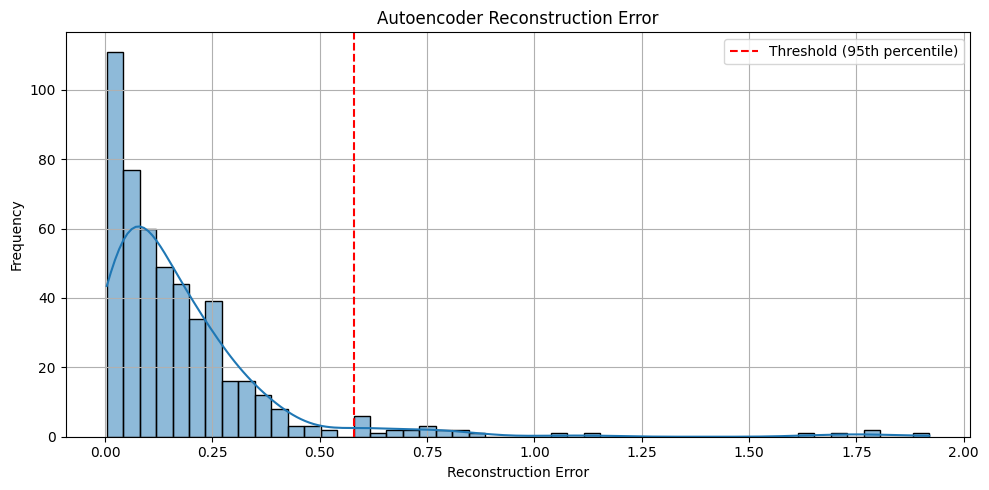

In [ ]:
print(f"\nAutoencoder anomaly threshold: {threshold}")
print(f"Anomalies detected: {df['anomaly_autoencoder'].sum()}")

plt.figure(figsize=(10, 5))
sns.histplot(df['reconstruction_error'], bins=50, kde=True)
plt.axvline(threshold, color='red', linestyle='--', label='Threshold (95th percentile)')
plt.title("Autoencoder Reconstruction Error")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

 One-Class SVM

In [ ]:
X_scaled_svm = scaler.fit_transform(X)

oc_svm = OneClassSVM(kernel='rbf', gamma='auto', nu=0.05)
oc_svm.fit(X_scaled_svm)

OneClassSVM(gamma='auto', nu=0.05)

In [ ]:
df['anomaly_score_svm'] = oc_svm.decision_function(X_scaled_svm)
df['anomaly_svm'] = oc_svm.predict(X_scaled_svm)

df['anomaly_svm'] = df['anomaly_svm'].map({1: 0, -1: 1})

svm_anomaly_count = df['anomaly_svm'].sum()

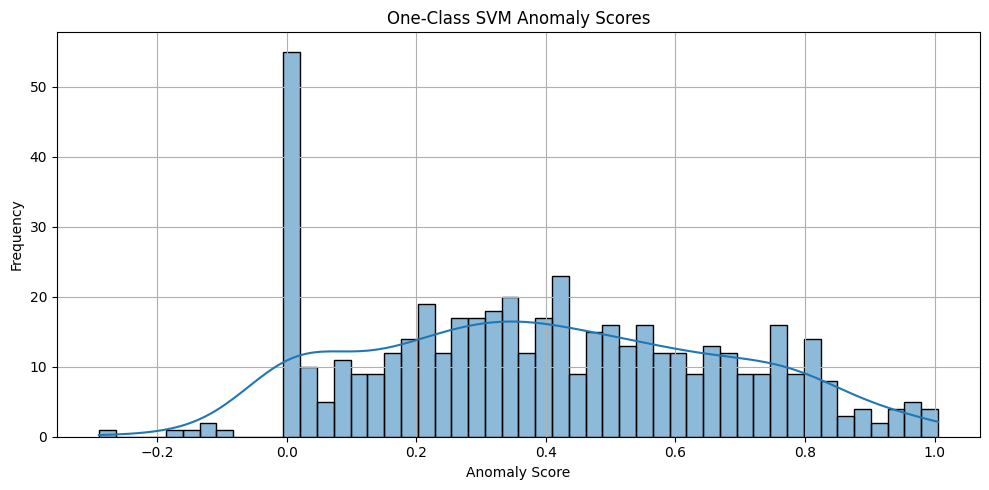

np.int64(31)

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['anomaly_score_svm'], bins=50, kde=True)
plt.title("One-Class SVM Anomaly Scores")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

svm_anomaly_count

SMOTE

In [ ]:
file_path2 = '/content/drive/MyDrive/Non-Trivial Submission/Leak and Anamoly Detection/water_network_with_failure_and_gis.csv'
df = pd.read_csv(file_path2)

In [ ]:
numerical_cols = ['PipeAge', 'Length_m', 'Diameter_mm', 'Pressure_psi', 'FlowRate_Lps']
categorical_cols = ['Zone', 'Material', 'ValveStatus']
X_cat = pd.get_dummies(df[categorical_cols], drop_first=True)
X_full = pd.concat([df[numerical_cols], X_cat], axis=1)
y = df['AcousticLeak']

X_train, X_test, y_train, y_test = train_test_split(X_full, y, test_size=0.2, stratify=y, random_state=42)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train_sm, y_train_sm)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred = xgb.predict(X_test)

In [ ]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[85  7]
 [ 8  0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.92      0.92        92
           1       0.00      0.00      0.00         8

    accuracy                           0.85       100
   macro avg       0.46      0.46      0.46       100
weighted avg       0.84      0.85      0.85       100



In [ ]:
failure_ratio = (y_train_sm == 0).sum() / (y_train_sm == 1).sum()

xgb_weighted = XGBClassifier(
    eval_metric='logloss',
    scale_pos_weight=failure_ratio,
    random_state=42
)
xgb_weighted.fit(X_train_sm, y_train_sm)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_weighted = xgb_weighted.predict(X_test)
conf_matrix_weighted = confusion_matrix(y_test, y_pred_weighted)
class_report_weighted = classification_report(y_test, y_pred_weighted, output_dict=True)

In [ ]:
feature_importances = pd.Series(
    xgb_weighted.feature_importances_,
    index=X_train_sm.columns
).sort_values(ascending=False)

In [ ]:
conf_matrix_weighted, class_report_weighted, feature_importances.head(10)

(array([[85,  7],
        [ 8,  0]]),
 {'0': {'precision': 0.9139784946236559,
   'recall': 0.9239130434782609,
   'f1-score': 0.918918918918919,
   'support': 92.0},
  '1': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 8.0},
  'accuracy': 0.85,
  'macro avg': {'precision': 0.45698924731182794,
   'recall': 0.46195652173913043,
   'f1-score': 0.4594594594594595,
   'support': 100.0},
  'weighted avg': {'precision': 0.8408602150537634,
   'recall': 0.85,
   'f1-score': 0.8454054054054054,
   'support': 100.0}},
 Zone_Z10                      0.183842
 ValveStatus_Open              0.088734
 Zone_Z4                       0.080503
 PipeAge                       0.075110
 ValveStatus_Partially Open    0.058648
 Zone_Z5                       0.057276
 Material_PVC                  0.044950
 Zone_Z7                       0.038424
 Zone_Z8                       0.037464
 Zone_Z2                       0.036601
 dtype: float32)

# **Demand Forecasting**

Dataset Upload and Imports

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

from prophet import Prophet

from statsmodels.tsa.arima.model import ARIMA

In [13]:
file_path3 = '/content/drive/MyDrive/Non-Trivial Submission/Demand Forecasting/synthetic_water_demand.csv'
df = pd.read_csv(file_path3, parse_dates=["date"])
df['month'] = df['date'].dt.month
df['dayofweek'] = df['date'].dt.dayofweek

for lag in range(1, 4):
    df[f'lag_{lag}'] = df['demand'].shift(lag)

df.dropna(inplace=True)

In [14]:
features = ['temperature', 'rainfall', 'population', 'month', 'dayofweek', 'lag_1', 'lag_2', 'lag_3']
X = df[features]
y = df['demand']

split = int(0.8 * len(df))
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
X_lstm = df[['lag_1', 'lag_2', 'lag_3']].values
X_lstm = X_lstm.reshape((X_lstm.shape[0], 3, 1))
X_train_lstm, X_test_lstm = X_lstm[:split], X_lstm[split:]

model_lstm = Sequential([
    LSTM(64, input_shape=(3, 1)),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_train_lstm, y_train, epochs=50, batch_size=16, verbose=0)

y_pred_lstm = model_lstm.predict(X_test_lstm).flatten()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


Random Forest Regression

In [16]:
rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

Support Vector Regression

In [17]:
svr = SVR(kernel='rbf')
svr.fit(X_train_scaled, y_train)
y_pred_svr = svr.predict(X_test_scaled)

Prophet (Meta)

In [19]:
df_prophet = df[['date', 'demand']].rename(columns={'date': 'ds', 'demand': 'y'})
prophet_model = Prophet(yearly_seasonality=True,
    daily_seasonality=True)
prophet_model.fit(df_prophet)
future = prophet_model.make_future_dataframe(periods=len(X_test))
forecast = prophet_model.predict(future)
y_pred_prophet = forecast['yhat'].values[-len(X_test):]

In [20]:
arima = ARIMA(df['demand'], order=(5, 1, 0)).fit()
arima_forecast = arima.forecast(steps=len(X_test))

residuals = df['demand'] - arima.predict()
ml_model = RandomForestRegressor()
ml_model.fit(X_train, residuals.iloc[:split])
residual_pred = ml_model.predict(X_test)
hybrid_pred = arima_forecast + residual_pred

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

Evaluation

In [21]:
def evaluate(y_true, y_pred, model_name):
    print(f"{model_name} MAE: {mean_absolute_error(y_true, y_pred):.2f}")
    print(f"{model_name} R²: {r2_score(y_true, y_pred):.2f}")

evaluate(y_test, y_pred_lstm, "LSTM")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_svr, "SVR")
evaluate(y_test, y_pred_prophet, "Prophet")
evaluate(y_test, hybrid_pred, "ARIMA + ML")

LSTM MAE: 55.01
LSTM R²: -39.68
Random Forest MAE: 4.29
Random Forest R²: 0.65
SVR MAE: 6.11
SVR R²: 0.11
Prophet MAE: 38.56
Prophet R²: -19.56
ARIMA + ML MAE: 18.16
ARIMA + ML R²: -4.11


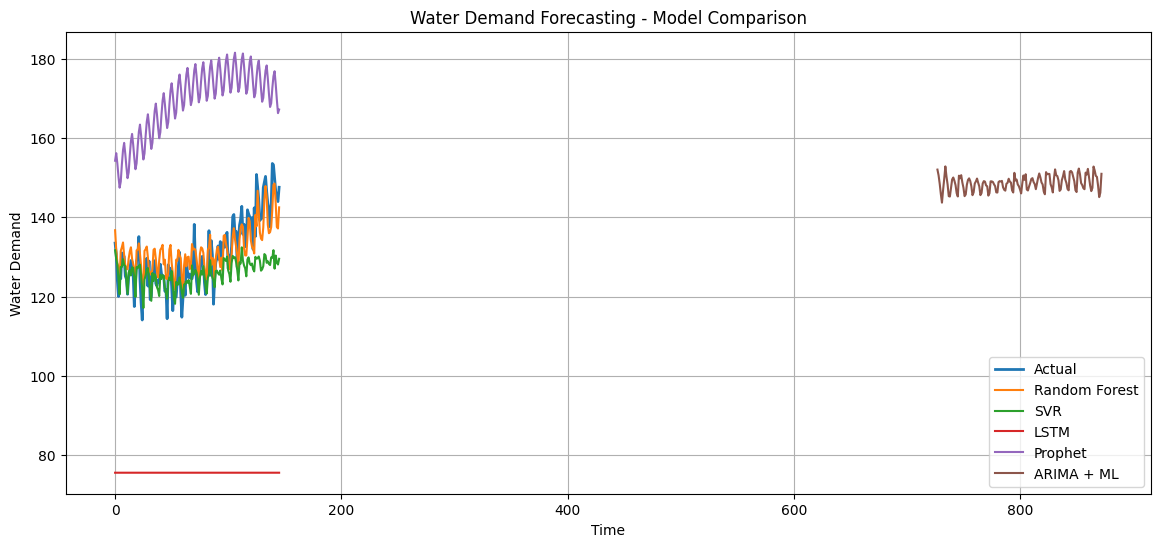

In [22]:
plt.figure(figsize=(14, 6))
plt.plot(y_test.values, label='Actual', linewidth=2)
plt.plot(y_pred_rf, label='Random Forest')
plt.plot(y_pred_svr, label='SVR')
plt.plot(y_pred_lstm, label='LSTM')
plt.plot(y_pred_prophet, label='Prophet')
plt.plot(hybrid_pred, label='ARIMA + ML')
plt.legend()
plt.title("Water Demand Forecasting - Model Comparison")
plt.xlabel("Time")
plt.ylabel("Water Demand")
plt.grid(True)
plt.show()

# **Energy Optimization**

In [2]:
%pip install pulp

Imports and Dataset Upload

In [3]:
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import tensorflow as tf
from tensorflow.keras import layers
from pulp import LpProblem, LpVariable, LpMinimize, lpSum
import matplotlib.pyplot as plt

In [4]:
data_path8 = '/content/drive/MyDrive/Non-Trivial Submission/Energy Optimization in Pumping Stations/synthetic_water_distribution_data.csv'
df = pd.read_csv(data_path8)

demand_series = df['Flow Demand (L/s)'].values

Pump Environment

In [5]:
max_pump = 100.0
max_storage = 1000.0
storage = max_storage / 2
t = 0

action_space = spaces.Box(low=0.0, high=max_pump, shape=(1,), dtype=np.float32)
observation_space = spaces.Box(low=0.0, high=np.array([np.max(demand_series), max_storage]), dtype=np.float32)

def reset_env():
    global storage, t
    storage = max_storage / 2
    t = 0
    return np.array([demand_series[t], storage], dtype=np.float32)

def step_env(action):
    global storage, t
    pump = float(np.clip(action, 0, max_pump))
    demand = demand_series[t]
    delivered = min(storage + pump, demand)
    storage = np.clip(storage + pump - delivered, 0, max_storage)
    cost_energy = pump**2
    penalty = 1000.0 * max(0, demand - delivered)
    reward = - (cost_energy + penalty)
    t += 1
    done = t >= len(demand_series)
    next_state = np.array([demand_series[t-1] if not done else 0, storage], dtype=np.float32)
    return next_state, reward, done, {}

/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


In [6]:
model = tf.keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])

target_model = tf.keras.models.clone_model(model)
target_model.set_weights(model.get_weights())

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
loss_fn = tf.keras.losses.MeanSquaredError()
replay_buffer = []

gamma = 0.99
epsilon = 1.0
eps_min = 0.01
eps_decay = 0.995
batch_size = 64

In [7]:
rewards_history = []

for episode in range(20):
    state = reset_env()
    done = False
    total_reward = 0

    while not done:
        if np.random.rand() < epsilon:
            action = np.array([action_space.sample()])
        else:
            q_val = model.predict(state[np.newaxis], verbose=0)
            action = np.array([q_val[0]])

        next_state, reward, done, _ = step_env(action)
        replay_buffer.append((state, action, reward, next_state, done))
        if len(replay_buffer) > 100000:
            replay_buffer.pop(0)

        if len(replay_buffer) >= batch_size:
            indices = np.random.choice(len(replay_buffer), batch_size, replace=False)
            batch = [replay_buffer[i] for i in indices]
            states, actions, rewards, next_states, dones = zip(*batch)
            states = np.vstack(states)
            next_states = np.vstack(next_states)

            targets = model.predict(states, verbose=0)
            next_q = target_model.predict(next_states, verbose=0)

            for i in range(batch_size):
                targets[i, 0] = rewards[i] + gamma * np.max(next_q[i]) * (1 - int(dones[i]))

            with tf.GradientTape() as tape:
                predictions = model(states)
                loss = loss_fn(targets, predictions)

            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

        state = next_state
        total_reward += reward

    # Update target network and decay epsilon
    target_model.set_weights(model.get_weights())
    epsilon = max(eps_min, epsilon * eps_decay)
    rewards_history.append(total_reward)
    print(f"Episode {episode+1}: Reward = {total_reward:.2f}, Epsilon = {epsilon:.3f}")

/tmp/ipykernel_1219/2984608603.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pump = float(np.clip(action, 0, max_pump))


Episode 1: Reward = -3355199.70, Epsilon = 0.995
Episode 2: Reward = -3348944.88, Epsilon = 0.990
Episode 3: Reward = -3395213.60, Epsilon = 0.985
Episode 4: Reward = -3268723.24, Epsilon = 0.980
Episode 5: Reward = -3293633.27, Epsilon = 0.975
Episode 6: Reward = -3248336.88, Epsilon = 0.970
Episode 7: Reward = -3097222.03, Epsilon = 0.966
Episode 8: Reward = -3209158.08, Epsilon = 0.961
Episode 9: Reward = -3371381.63, Epsilon = 0.956
Episode 10: Reward = -3196317.86, Epsilon = 0.951
Episode 11: Reward = -3151803.23, Epsilon = 0.946
Episode 12: Reward = -3326863.02, Epsilon = 0.942
Episode 13: Reward = -3321750.88, Epsilon = 0.937
Episode 14: Reward = -3197599.01, Epsilon = 0.932
Episode 15: Reward = -3184336.72, Epsilon = 0.928
Episode 16: Reward = -3222755.64, Epsilon = 0.923
Episode 17: Reward = -3294728.21, Epsilon = 0.918
Episode 18: Reward = -3056911.11, Epsilon = 0.914
Episode 19: Reward = -3279665.20, Epsilon = 0.909
Episode 20: Reward = -3043230.19, Epsilon = 0.905


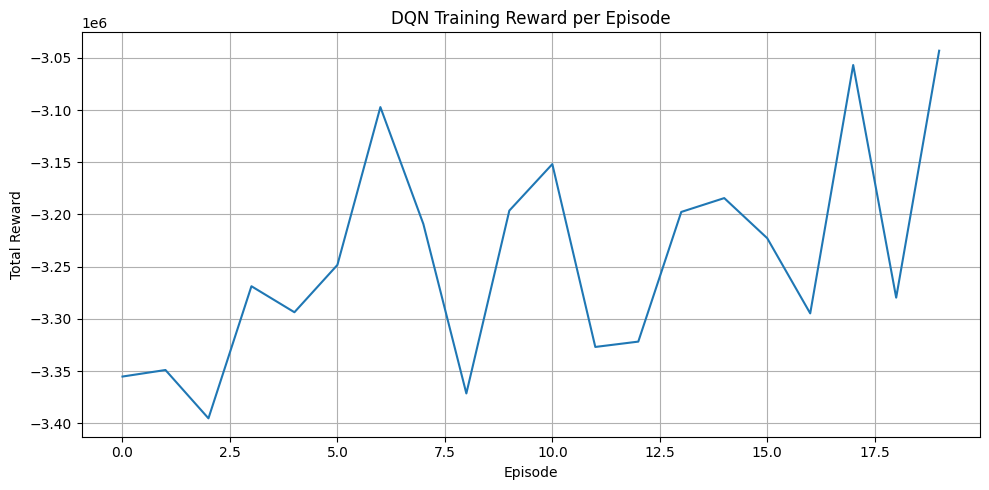

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(rewards_history)
plt.title('DQN Training Reward per Episode')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
forecast_horizon = 24
forecast_demand = demand_series[-forecast_horizon:]

lp_prob = LpProblem("PumpScheduling", LpMinimize)
lp_vars = {t: LpVariable(f"pump_{t}", lowBound=0, upBound=max_pump) for t in range(forecast_horizon)}
lp_prob += lpSum([lp_vars[t] for t in range(forecast_horizon)])

for t in range(forecast_horizon):
    lp_prob += lp_vars[t] >= forecast_demand[t]

lp_prob.solve()
lp_schedule = [lp_vars[t].varValue for t in range(forecast_horizon)]

In [10]:
dqn_schedule = []
t = len(demand_series) - forecast_horizon
storage = max_storage / 2
state = np.array([forecast_demand[0], storage], dtype=np.float32)

for _ in range(forecast_horizon):
    q_val = model.predict(state[np.newaxis], verbose=0)
    action = float(np.clip(q_val[0], 0, max_pump))
    dqn_schedule.append(action)

    demand = forecast_demand[_]
    delivered = min(storage + action, demand)
    storage = np.clip(storage + action - delivered, 0, max_storage)
    t += 1
    state = np.array([forecast_demand[_] if _ < forecast_horizon - 1 else 0, storage], dtype=np.float32)

/tmp/ipykernel_1219/163047722.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  action = float(np.clip(q_val[0], 0, max_pump))


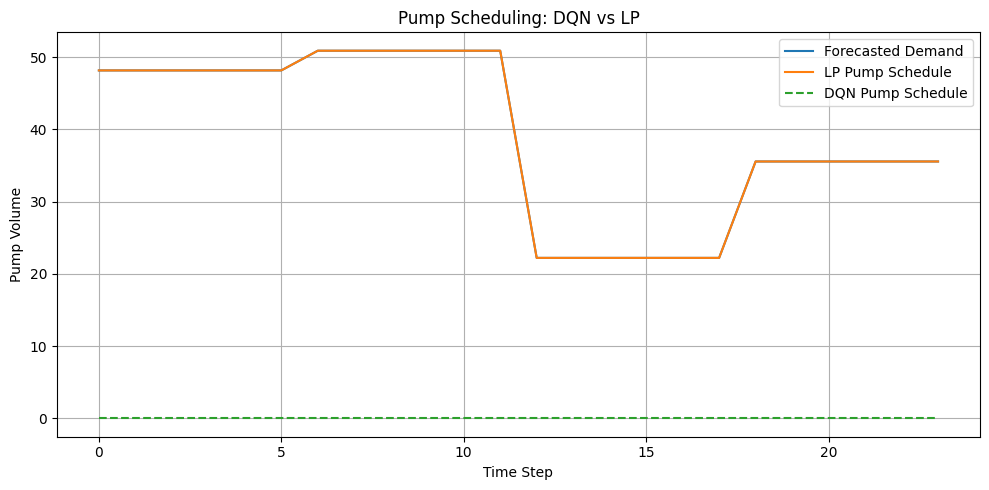

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(forecast_demand, label="Forecasted Demand")
plt.plot(lp_schedule, label="LP Pump Schedule")
plt.plot(dqn_schedule, label="DQN Pump Schedule", linestyle='--')
plt.title("Pump Scheduling: DQN vs LP")
plt.xlabel("Time Step")
plt.ylabel("Pump Volume")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()